In [1]:
import numpy as np
import tqdm
import matplotlib.pyplot as plt

from torque_lever_cython import CythonTorqueLeverStep, fit_force_cython
import physics_model

In [2]:
class DummyForce(physics_model.TorqueLeverSimulation):
    def __init__(self):
        tt = np.linspace(0, 1, 500)
        super().__init__(lever_mass = 3.5e-3,    #kg
                         lever_length = 15e-2,   #meter
                         lever_range = (30, 100), #degrees
                         motor_baseline_torque = 3e-3,
                         motor_extra_torque = 2e-2,
                         motor_onset_angle = (75, 80),
                         friction_coeff = 0.0e-3,
                         dt=1e-3)
        self.dummy_force = -np.sin(4*tt)**2*tt - 0.1*tt**2
    
    def get_torque_rat(self):
        force = self.dummy_force[int(self.time / self.dt)]
        torque = force * self.lever_length * np.sin(self.theta) / 2
        return torque
df = DummyForce()
res = df.simulate_trial(duration=0.5)
ref_thetas = res["theta"]
ref_forces = df.dummy_force

In [3]:
cython_step = CythonTorqueLeverStep(
    lever_mass=3.5e-3,
    lever_length=15e-2,
    lever_range=(30, 100),
    motor_baseline_torque=3e-3,
    motor_extra_torque=2e-2,
    motor_onset_angle=(75, 80),
    friction_coeff=0.0e-3,
    dt=1e-3
)

In [ ]:
force_est = fit_force_cython(ref_thetas, cython_step,
                             theta_dot_min=-25, theta_dot_max=25, theta_dot_n_bins=100,
                             theta_offset_min=-np.deg2rad(20), theta_offset_max=np.deg2rad(20), theta_offset_n_bins=40)

In [6]:
force_est

array([-0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
       -0.15, -0.15,

In [11]:
ref_forces.max()

np.float64(-0.0)

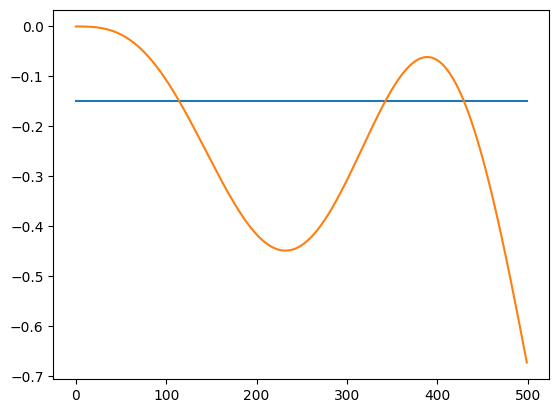

In [5]:
plt.plot(force_est)
plt.plot(ref_forces)

In [21]:
df = DummyForce()
df.dummy_force = force_est
re_sim = df.simulate_trial(0.5)

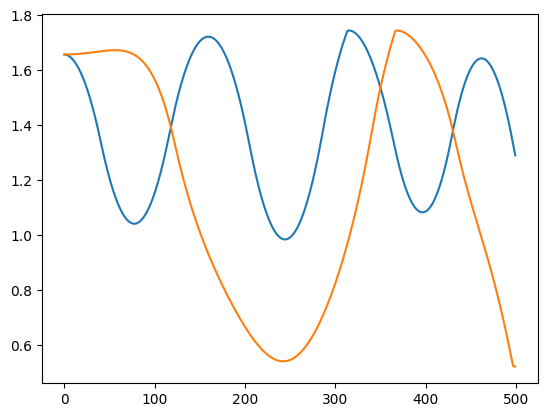

In [23]:
plt.plot(re_sim["theta"])
plt.plot(ref_thetas)